# Toy four-state thermodynamic model

A small, self-contained simulator for building intuition about the curves that
`tfs-cat-response` and `tfs-extract-epistasis` extract. No JAX, no config files —
just NumPy/SciPy/pandas, meant to be poked at interactively.

**The system** (a monomer TF, activity fixed at 1, pure repressor):

$$\mathrm{HD} \rightleftharpoons \mathrm{H} + \mathrm{D} \rightleftharpoons \mathrm{L} + \mathrm{D} \rightleftharpoons \mathrm{LE} + \mathrm{D}$$

- **H, L** — two protein conformations in intrinsic equilibrium.
- **D** — DNA (operator); the H conformation binds it to form **HD**.
- **E** — effector (the titrant); the L conformation binds it to form **LE**.
- **Observable** = $\mathrm{HD}/(\mathrm{HD}+\mathrm{D})$, the fraction of DNA bound (repression).

Three wild-type association constants set the system: `K_conf = [H]/[L]`,
`K_dna = [HD]/([H][D])`, `K_eff = [LE]/([L][E])`. As effector rises, protein is
pulled into LE, HD falls, and the observable drops — de-repression.

Mutations perturb the **stability of each state** (HD, H, L, LE) independently in
units of kT (positive = destabilizing), with optional **in-state pairwise
epistasis**. That's the only epistasis in the model — yet, as we'll see, the
*observable* shows plenty of its own, purely from the nonlinear map.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tfscreen.simulate.toy_thermo import (
    ThermoModel, MutationEffects, sample_effects,
    build_titration_df, enumerate_genotypes, solve_species,
)

# A wild-type system: strong DNA binding, moderate effector affinity, K_conf ~ 1.
model = ThermoModel(
    ln_K_conf=0.0,      # H and L equally populated in the apo state
    ln_K_dna=18.0,      # tight operator binding
    ln_K_eff=14.0,      # effector affinity
    protein_total=1e-6, # all concentrations share one unit (say, M)
    dna_total=1e-9,     # operator is scarce relative to protein
)

effector = np.logspace(-8, -2, 25)   # titration grid

/Users/harmsm/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The wild-type titration curve

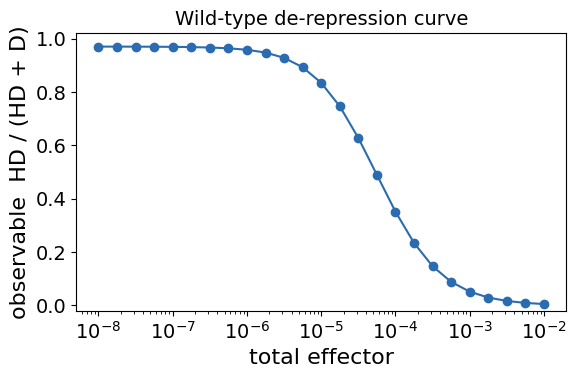

In [2]:
theta_wt = model.observable(effector, genotype="wt")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(effector, theta_wt, "o-", color="#2b6cb0")
ax.set_xlabel("total effector")
ax.set_ylabel("observable  HD / (HD + D)")
ax.set_title("Wild-type de-repression curve")
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()

## 2. What the protein is doing under the hood

`solve_species` returns every free/bound concentration at one effector value, so
we can watch the population shift from operator-bound (HD) to effector-bound (LE)
as the titrant increases.

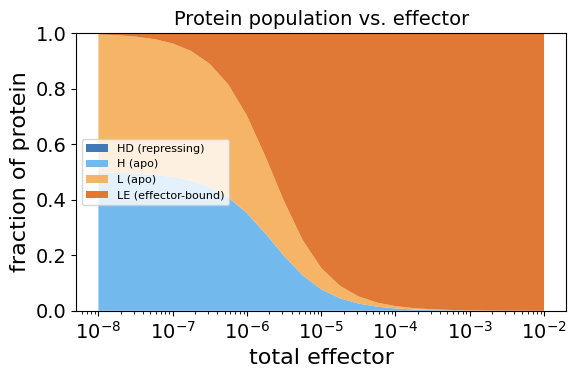

In [3]:
species = [solve_species(*model.genotype_ks("wt"),
                         model.protein_total, model.dna_total, E)
           for E in effector]

frac = {s: np.array([sp[s] for sp in species]) / model.protein_total
        for s in ("HD", "H", "L", "LE")}

fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(effector, frac["HD"], frac["H"], frac["L"], frac["LE"],
             labels=["HD (repressing)", "H (apo)", "L (apo)", "LE (effector-bound)"],
             colors=["#2b6cb0", "#63b3ed", "#f6ad55", "#dd6b20"], alpha=0.9)
ax.set_xscale("log")
ax.set_xlabel("total effector")
ax.set_ylabel("fraction of protein")
ax.set_title("Protein population vs. effector")
ax.set_ylim(0, 1)
ax.legend(loc="center left", fontsize=8)
fig.tight_layout()

## 3. Manual mutations as `ddg` kwargs

For a quick one-off, pass a per-state `ddg` dict straight to `observable`. Each
value is a stability change in kT; omitted states are 0. Watch how perturbing
different states reshapes the curve differently:

- destabilizing **HD** (+kT) weakens repression → the whole curve drops;
- stabilizing **LE** (−kT) makes effector bind more easily → the curve shifts left.

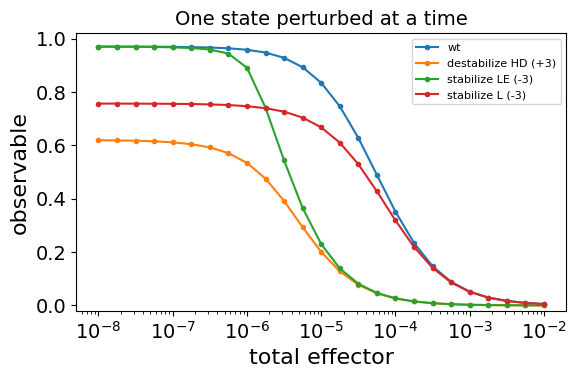

In [4]:
variants = {
    "wt": {},
    "destabilize HD (+3)": {"HD": 3.0},
    "stabilize LE (-3)": {"LE": -3.0},
    "stabilize L (-3)": {"L": -3.0},
}

fig, ax = plt.subplots(figsize=(6, 4))
for label, ddg in variants.items():
    ax.semilogx(effector, model.observable(effector, ddg=ddg), "o-", ms=3, label=label)
ax.set_xlabel("total effector")
ax.set_ylabel("observable")
ax.set_title("One state perturbed at a time")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()

## 4. A named mutation catalog + a titration table

`MutationEffects` holds named mutations and their (optional) in-state pairwise
epistasis. `build_titration_df` then enumerates wt + singles + doubles and emits
the long-form table the analysis tools consume.

> **Naming:** `cat_response` accepts any labels, but `extract_epistasis` requires
> the `XsiteY` convention (e.g. `A1V`, `A2V` → `A1V/A2V`). We use it throughout so
> both tools are happy.

In [5]:
effects = (MutationEffects()
           .add_mutation("A1V", HD=0.0)      # weakens repression
           .add_mutation("A2V", LE=0.0)     # tightens effector binding
           .add_epistasis("A1V", "A2V"))     # NB: zero thermodynamic epistasis

df = build_titration_df(model, effector, effects=effects,
                        observable_std=0.02)
print("genotypes:", sorted(df['genotype'].unique()))
df.head()

genotypes: ['A1V', 'A1V/A2V', 'A2V', 'wt']


,genotype,titrant_name,titrant_conc,observable,observable_std
0,wt,effector,1.000000e-08,0.970305,0.02
1,wt,effector,1.778279e-08,0.970220,0.02
2,wt,effector,3.162278e-08,0.970070,0.02
3,wt,effector,5.623413e-08,0.969802,0.02
4,wt,effector,1.000000e-07,0.969320,0.02


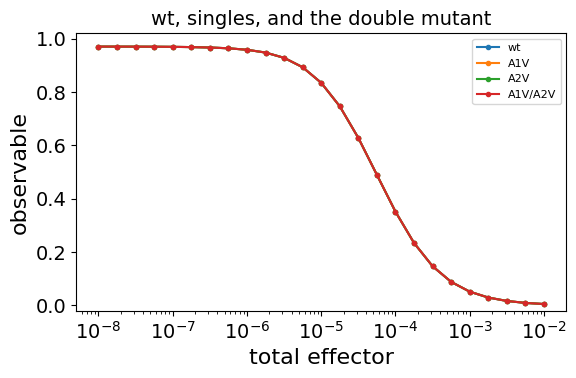

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for geno in enumerate_genotypes(effects.mutations, order=2):
    sub = df[df["genotype"] == geno]
    ax.semilogx(sub["titrant_conc"], sub["observable"], "o-", ms=3, label=geno)
ax.set_xlabel("total effector")
ax.set_ylabel("observable")
ax.set_title("wt, singles, and the double mutant")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()

## 5. Classify each curve with `tfs-cat-response`

Feed the table straight in: `genotype` is the grouping axis, `titrant_conc` is
x, `observable` is y, `observable_std` is the weight.

In [7]:
from tfscreen.analysis.cat_response.cat_response import cat_response

results, predictions, assessment, delta = cat_response(
    df, x_obs="titrant_conc", y_obs="observable", y_std="observable_std",
    progress=False)

results[["genotype", "best_model", "shape", "fittable", "nonzero_q"]]

,genotype,best_model,shape,fittable,nonzero_q
0,wt,repressor,step,True,0.0
1,A1V,repressor,step,True,0.0
2,A2V,repressor,step,True,0.0
3,A1V/A2V,repressor,step,True,0.0


## 6. The punchline: observable epistasis with *no* thermodynamic epistasis

We set `add_epistasis("A1V", "A2V")` with **all-zero** state effects — there is no
thermodynamic interaction between the two mutations. Yet `extract_epistasis`
reports substantial epistasis in the observable, and it **flips sign across the
titration**. That is the pure nonlinearity of $\mathrm{HD}/(\mathrm{HD}+\mathrm{D})$,
not a property of the underlying biophysics — exactly the trap to watch for when
interpreting real epistasis curves.

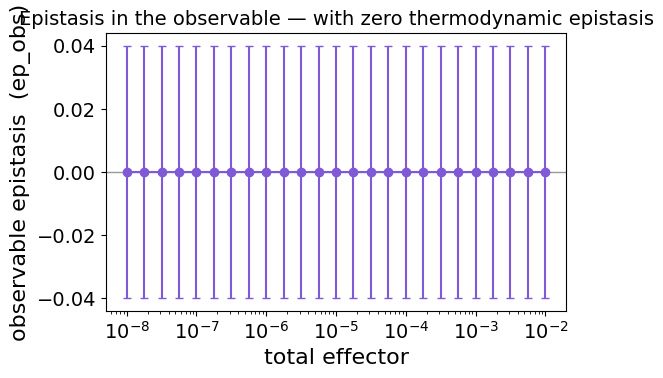

In [8]:
from tfscreen.analysis.extract_epistasis import extract_epistasis

ep = extract_epistasis(df, y_obs="observable", y_std="observable_std",
                       group_by="titrant_conc")

sub = ep[ep["genotype"] == "A1V/A2V"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color="0.6", lw=1)
ax.errorbar(sub["titrant_conc"], sub["ep_obs"], yerr=sub["ep_std"],
            fmt="o-", color="#805ad5", capsize=3)
ax.set_xscale("log")
ax.set_xlabel("total effector")
ax.set_ylabel("observable epistasis  (ep_obs)")
ax.set_title("Epistasis in the observable — with zero thermodynamic epistasis")
fig.tight_layout()

Try flipping on a real interaction — e.g. `.add_epistasis("A1V", "A2V", HD=2.0)` —
and re-running from cell 4. The curve's shape and baseline both change, and you
can start to build intuition for which thermodynamic interactions produce which
observable signatures.

## 7. Random libraries with the sampler

Instead of hand-setting every effect, draw them from per-state Normals. Each
value is either an sd (mean 0) or a `(mean, sd)` tuple. Handy for generating a
library of curves to stress-test the analysis tools.

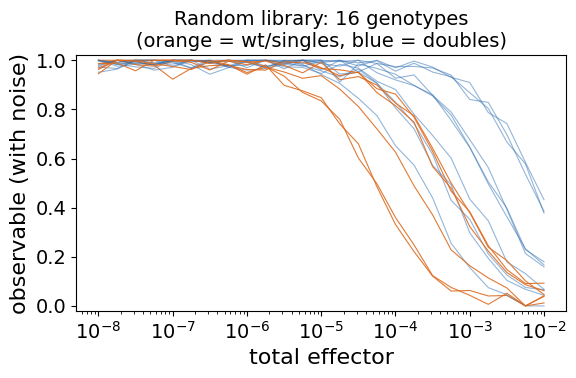

In [9]:
muts = [f"A{i}V" for i in range(1, 6)]   # A1V ... A5V
rng = np.random.default_rng(0)

rand_effects = sample_effects(
    muts,
    effect_sd={"HD": 1.5, "H": 0.5, "L": 0.5, "LE": 1.5},
    epistasis_sd={"HD": 0.3, "LE": 0.3},
    rng=rng,
)

rand_df = build_titration_df(model, effector, effects=rand_effects,
                            observable_std=0.02, noise_sd=0.02, rng=rng)

fig, ax = plt.subplots(figsize=(6, 4))
for geno, sub in rand_df.groupby("genotype"):
    ax.semilogx(sub["titrant_conc"], sub["observable"], "-", lw=0.8,
                color="#2b6cb0" if "/" in geno else "#dd6b20",
                alpha=0.5 if "/" in geno else 0.9)
ax.set_xlabel("total effector")
ax.set_ylabel("observable (with noise)")
ax.set_title(f"Random library: {rand_df['genotype'].nunique()} genotypes\n"
             "(orange = wt/singles, blue = doubles)")
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()

From here you can run `cat_response` / `extract_epistasis` on `rand_df` just as
above, or tune `ln_K_*`, the concentrations, and the effect distributions to
explore how the observable curves — and their apparent epistasis — respond.

---

## 8. Ensemble vs. within-state epistasis, on the logit scale

The observable stacks two nonlinearities, and separating them is the whole game
when you try to read epistasis curves:

1. **DNA-binding saturation**, `theta = W/(1+W)` — a pure monotone squashing
   shared by *every* mutation. It is what produced the sign-flipping,
   diminishing-returns epistasis on the raw scale, and the `logit` link removes it
   completely.
2. **Free-protein reweighting**, the `ln(exp(-g_L) + exp(-g_H) + [E]*exp(-g_LE))`
   log-sum-exp — the genuinely allosteric part, which `logit` does *not* remove.

In the protein-excess / trace-operator limit (the defaults here),

$$\operatorname{logit}\theta \;\approx\; c \;-\; g_{HD} \;-\; \ln\!\big(e^{-g_L} + e^{-g_H} + [E]\,e^{-g_{LE}}\big).$$

`logit theta` is **linear in `g_HD`** and convex through the log-sum-exp in the
other states. To second order the additive (no-interaction) epistasis is a
**population covariance**, `eps_logit ≈ -Cov_p(delta_A, delta_B)`, so it is nonzero
only where the free-protein ensemble is *mixed*. A genuine within-state
interaction `e_AB` instead adds a term of a *different form*: a flat `-e` if it
sits on `g_HD`, or an occupancy `p_k([E])*e` if it sits on a free state. The two
figures below make that contrast concrete.

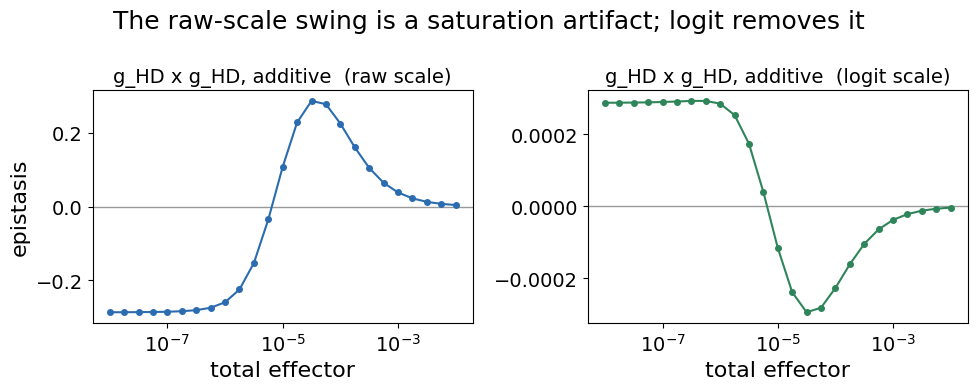

In [10]:
from scipy.special import logit


def epistasis_curve(model, E, ddg_A, ddg_B, epi=None, scale="logit"):
    """Additive epistasis (11-10)-(01-00) vs. effector, on the raw or logit scale.

    ddg_A, ddg_B : per-state ddG dicts for the two single mutants (additive).
    epi          : per-state within-state interaction applied ONLY to the double.
    """
    epi = epi or {}
    states = set(ddg_A) | set(ddg_B) | set(epi)
    ddg_AB = {s: ddg_A.get(s, 0.0) + ddg_B.get(s, 0.0) + epi.get(s, 0.0) for s in states}
    y = {g: model.observable(E, ddg=d)
         for g, d in [("00", {}), ("10", ddg_A), ("01", ddg_B), ("11", ddg_AB)]}
    link = ((lambda v: logit(np.clip(v, 1e-12, 1 - 1e-12))) if scale == "logit"
            else (lambda v: v))
    return (link(y["11"]) - link(y["10"])) - (link(y["01"]) - link(y["00"]))


# Same additive g_HD mutations, viewed on each scale.
ddg = {"HD": 2.0}
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, scale, color in zip(axes, ["raw", "logit"], ["#2b6cb0", "#2f855a"]):
    ax.axhline(0, color="0.6", lw=1)
    ax.semilogx(effector, epistasis_curve(model, effector, ddg, ddg, scale=scale),
                "o-", ms=4, color=color)
    ax.set_xlabel("total effector")
    ax.set_title(f"g_HD x g_HD, additive  ({scale} scale)")
axes[0].set_ylabel("epistasis")
fig.suptitle("The raw-scale swing is a saturation artifact; logit removes it")
fig.tight_layout()

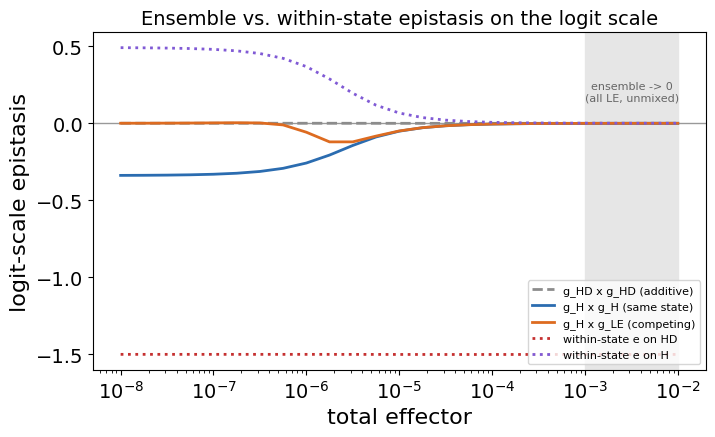

In [11]:
channels = [
    ("g_HD x g_HD (additive)",     dict(ddg_A={"HD": 2.0}, ddg_B={"HD": 2.0}),                  "0.55",    "--"),
    ("g_H x g_H (same state)",     dict(ddg_A={"H": 1.5},  ddg_B={"H": 1.5}),                   "#2b6cb0", "-"),
    ("g_H x g_LE (competing)",     dict(ddg_A={"H": 1.5},  ddg_B={"LE": -1.5}),                 "#dd6b20", "-"),
    ("within-state e on HD",       dict(ddg_A={"HD": 2.0}, ddg_B={"HD": 2.0}, epi={"HD": 1.5}), "#c53030", ":"),
    ("within-state e on H",        dict(ddg_A={"HD": 2.0}, ddg_B={"HD": 2.0}, epi={"H": 1.5}),  "#805ad5", ":"),
]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.axvspan(1e-3, effector[-1], color="0.9", zorder=0)          # unmixed (all-LE) readout zone
ax.axhline(0, color="0.6", lw=1)
for label, kw, color, ls in channels:
    e = epistasis_curve(model, effector, scale="logit", **kw)
    ax.semilogx(effector, e, ls, color=color, lw=2, label=label)
ax.text(3.2e-3, 0.15, "ensemble -> 0\n(all LE, unmixed)", fontsize=8, color="0.4", ha="center")
ax.set_xlabel("total effector")
ax.set_ylabel("logit-scale epistasis")
ax.set_title("Ensemble vs. within-state epistasis on the logit scale")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

### Reading the panel

- **`g_HD × g_HD` (grey dashed) is flat at zero.** Two mutations that are additive
  in energy and act through the operator-affinity channel have *no* epistasis on
  the logit scale, at any concentration. The large raw-scale swing (left figure)
  was entirely the DNA-saturation squashing — a scale artifact.
- **The two ensemble channels (`g_H×g_H`, `g_H×g_LE`) live only where the
  free-protein ensemble is mixed** and vanish at the **high-effector plateau**
  (everything is LE — unmixed). Note `g_H×g_H` is *large at low effector even
  though the observable is plateaued there*: L and H are still 50/50, a hidden
  conformational transition. Epistasis on a flat part of the observable is an
  ensemble tell. `g_H×g_LE` is silent until LE starts to populate, then switches
  on — its onset tracks the ligand transition, not the binding curve.
- **The within-state interactions do not follow the covariance shape.**
  `e_AB` on `g_HD` is a **flat offset at every concentration**, including the
  high-effector plateau where all ensemble channels have died — that residue is
  the clean readout. `e_AB` on `g_H` tracks the H occupancy `p_H([E])`: a single
  monotone step, no sign structure.

**Practical upshot.** Do epistasis extraction on **logit θ**, and read the
**plateaus**: at the fully-liganded end, additive/ensemble terms go to zero and
only genuine within-state coupling survives. A single static monotone scale
removes the `g_HD` channel everywhere but *cannot* flatten the ensemble channels
at all concentrations at once — that irremovability is the signature.

Things to try: set `ln_K_conf=4` so H dominates at low effector — the low-E
ensemble epistasis now vanishes too (ensemble unmixed at *both* ends), confirming
the low-E signal above was the hidden L/H mixing. Or separate the conformational
and ligand transitions in `[E]` to hunt for a two-lobed `ε(E)`.

---

## 9. From curves to mechanism: the basis-curve decomposition

Section 8 showed that logit epistasis separates into an *ensemble* (redistribution)
part and a *within-state* (direct) part. We can make that exact and turn it into a
lookup table. Two facts do all the work:

**(a) A single genotype's curve can never peak.** Because
$\operatorname{logit}\theta = -g_{HD} + \ln[L_\text{free}] + \text{const}$ and free
$[L]$ is *strictly monotone-decreasing* in effector (mass balance), every single
genotype's $\theta$ and $\operatorname{logit}\theta$ curve is monotone. **All peaks
live in the epistasis second difference** — exactly where you see them in the real
data.

**(b) Additive epistasis is a combination of three basis curves.** Using
$\operatorname{Cov}_p(a,b)=\sum_{j<k}p_jp_k(a_j-a_k)(b_j-b_k)$,

$$\varepsilon_\text{add}(E) = -\!\!\sum_{j<k\,\in\,\{L,H,LE\}}\!\!(\Delta_A^{jk})(\Delta_B^{jk})\;p_j(E)\,p_k(E),$$

so every additive double-mutant epistasis curve is a linear combination of just
**three occupancy products**: $p_Lp_H$, $p_Lp_{LE}$, $p_Hp_{LE}$. The
`toy_thermo.basis` module exposes these plus the coefficient bookkeeping, the
second-order prediction, and the exact curve.

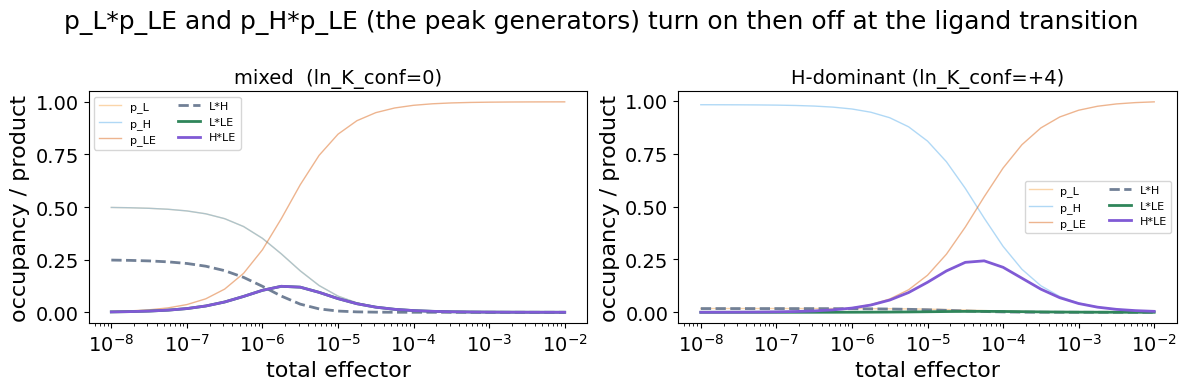

In [12]:
from tfscreen.simulate.toy_thermo import (
    basis_curves, epistasis_coeffs, predict_epistasis, exact_epistasis,
    classify_shape, plot_basis, plot_epistasis_decomposition,
)

# The basis curves depend only on the *backdrop* (the wt ensemble), not on any
# mutation. Compare a mixed apo state (ln_K_conf=0) with an H-dominant one (+4).
backdrops = {
    "mixed  (ln_K_conf=0)":       ThermoModel(0.0, 18.0, 14.0, 1e-6, 1e-9),
    "H-dominant (ln_K_conf=+4)":  ThermoModel(4.0, 18.0, 14.0, 1e-6, 1e-9),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, mdl) in zip(axes, backdrops.items()):
    plot_basis(mdl, effector, ax=ax)
    ax.set_title(label)
fig.suptitle("p_L*p_LE and p_H*p_LE (the peak generators) turn on then off at the "
             "ligand transition")
fig.tight_layout()

### The peak recipe

A double-mutant epistasis curve **peaks** iff it puts weight on a $p_\cdot p_{LE}$
basis curve — i.e. **one mutation contrasts an occupied apo state ($L$ or $H$)
against $LE$, and its partner contrasts the same pair.** Then:

- **peak location** = the ligand transition midpoint (where $p_{LE}\!\approx\!0.5$).
  To leading order this is the *wt* transition (set by `ln_K_eff`/`protein_total`),
  because the basis curves are the wt ensemble occupancies. It is **not** strictly
  mutation-independent, though: a mutation that perturbs $g_{LE}$ shifts *its own*
  genotype's transition ($\ln K_{eff}\!\to\!\ln K_{eff}-\Delta g_{LE}$), so the exact
  peak is a blend across the wt/A/B/AB quartet — it drifts toward the $LE$-perturbed
  members as $|\Delta g_{LE}|$ grows, and eventually splits into two lobes
  (*biphasic*). The non-$LE$ partner sets amplitude/sign, not location.
- **peak sign** = $-(\Delta_A)(\Delta_B)$ across that state pair.

`epistasis_coeffs` reads the coefficients straight off the two ddG vectors, and
`plot_epistasis_decomposition` overlays the exact curve, the second-order
prediction, and each contribution — so you can see which basis curve makes the
peak and how far second order drifts (the closed form is exact only in the
no-depletion limit; here it runs ~15 % high in magnitude but keeps the shape).

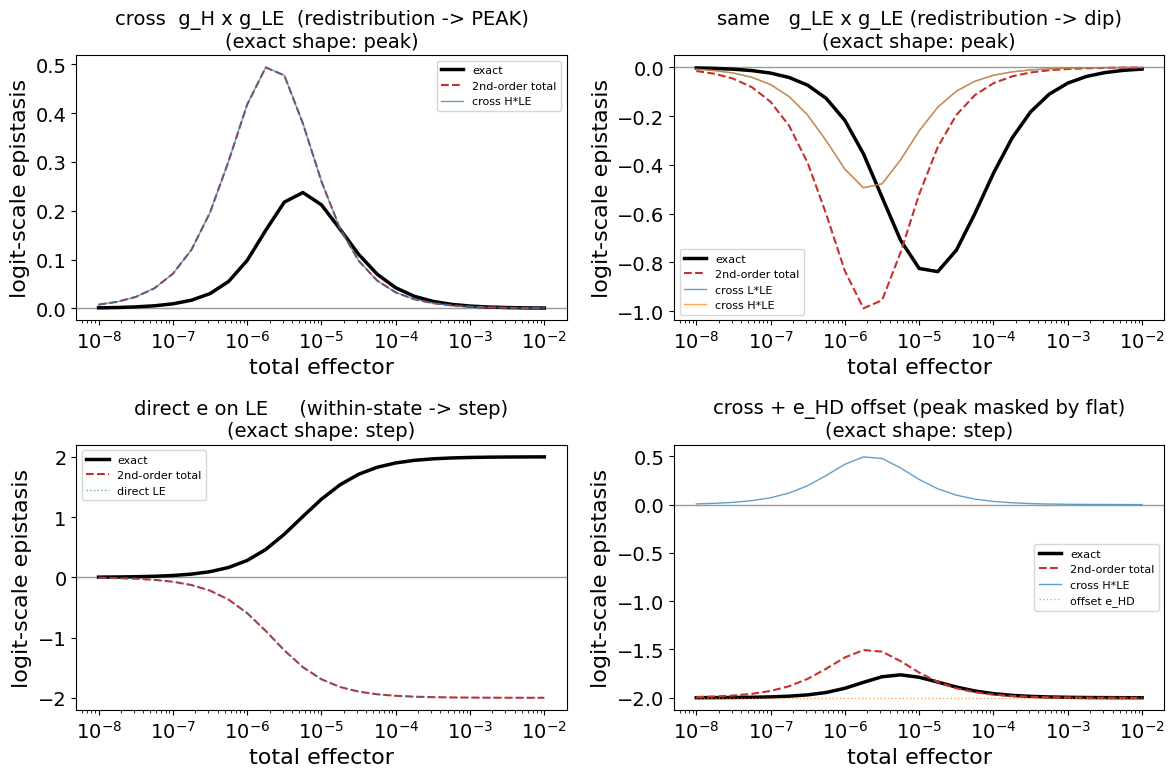

In [13]:
mdl = backdrops["mixed  (ln_K_conf=0)"]

# Four mechanisms, one per panel. (ddg_A, ddg_B, epi)
demo = [
    ("cross  g_H x g_LE  (redistribution -> PEAK)", {"H": 2.0}, {"LE": 2.0}, None),
    ("same   g_LE x g_LE (redistribution -> dip)",  {"LE": 2.0}, {"LE": 2.0}, None),
    ("direct e on LE     (within-state -> step)",   {}, {}, {"LE": 2.0}),
    ("cross + e_HD offset (peak masked by flat)",   {"H": 2.0}, {"LE": 2.0}, {"HD": 2.0}),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (title, a, b, epi) in zip(axes.ravel(), demo):
    plot_epistasis_decomposition(mdl, effector, a, b, epi=epi, ax=ax)
    ax.set_title(title + f"\n(exact shape: {classify_shape(exact_epistasis(mdl, effector, a, b, epi))})")
fig.tight_layout()

### The screen: mechanism → shape, without enumerating billions

The naive double-mutant space is enormous ($\sim3.5\times10^9$), but the shape of
the epistasis curve is fixed by (i) which **basis curve** the pair activates and
(ii) the **backdrop** (which apo state is populated). So we scan a handful of
mechanistic *channels* across a few backdrops — a couple dozen curves — and compare
each channel's noise-free **intrinsic** shape with the shape `cat_response`
**observes** once a realistic measurement noise floor is added (the same classifier
you run on real data). The genuine `build_titration_df → extract_epistasis`
pipeline, and the logit-error caveat, follow below.

In [14]:
import pandas as pd
from tfscreen.analysis.cat_response.cat_response import cat_response

# Mechanistic channels: (name, ddg_A, ddg_B, epi).  Names encode the mechanism.
channels = [
    ("redist_cross_H_LE",  {"H": 2.0},  {"LE": 2.0}, None),
    ("redist_cross_L_LE",  {"L": 2.0},  {"LE": 2.0}, None),
    ("redist_cross_H_L",   {"H": 2.0},  {"L": 2.0},  None),
    ("redist_same_LE",     {"LE": 2.0}, {"LE": 2.0}, None),
    ("redist_same_H",      {"H": 2.0},  {"H": 2.0},  None),
    ("direct_e_LE",        {},          {},          {"LE": 2.0}),
    ("direct_e_H",         {},          {},          {"H": 2.0}),
    ("direct_e_HD",        {},          {},          {"HD": 2.0}),
]
screen_backdrops = {"L_dom(-4)": -4.0, "mixed(0)": 0.0, "H_dom(+4)": 4.0}


def intrinsic_shape(y, tol=1e-2):
    """Ground-truth label of a noise-free epistasis curve: flat/step/peak/dip.

    Judged by the *span* (E-dependence), so a constant offset -- e.g. a within-HD
    interaction -- reads 'flat' regardless of its level.
    """
    y = np.asarray(y, dtype=float)
    if float(y.max() - y.min()) < tol:
        return "flat"                       # no E-dependence, any offset
    yc = y - 0.5 * (y[0] + y[-1])           # center on the endpoints
    i = int(np.argmax(np.abs(yc)))
    interior = 3 <= i <= len(y) - 4 and abs(yc[i]) > 1.3 * max(abs(yc[0]), abs(yc[-1]))
    if not interior:
        return "step"
    return "peak" if yc[i] > 0 else "dip"


SIGMA = 0.05                                # realistic measurement noise
rng = np.random.default_rng(0)
truth_rows, obs_rows = [], []
for bname, lnc in screen_backdrops.items():
    mdl_b = ThermoModel(lnc, 18.0, 14.0, 1e-6, 1e-9)
    for cname, a, b, epi in channels:
        eps = exact_epistasis(mdl_b, effector, a, b, epi)
        truth_rows.append({"genotype": cname, "backdrop": bname,
                           "shape_true": intrinsic_shape(eps)})
        obs_rows.append(pd.DataFrame({
            "genotype": cname, "backdrop": bname, "titrant_conc": effector,
            "ep_obs": eps + rng.normal(0.0, SIGMA, effector.size), "ep_std": SIGMA}))

# Ground truth: mechanism -> intrinsic shape (noise-free, deterministic).
truth = (pd.DataFrame(truth_rows)
         .pivot(index="genotype", columns="backdrop", values="shape_true")
         .reindex([c[0] for c in channels]))

# Observed: what cat_response reliably calls each curve at SIGMA noise. We use the
# conservative 'aicc' selector (penalizes extra peak params) so the table reflects
# shapes you can trust; 'shape' mode is the liberal, exploratory alternative and
# will over-call structure on low-amplitude curves.
obs_res, _, _, _ = cat_response(
    pd.concat(obs_rows, ignore_index=True), x_obs="titrant_conc",
    y_obs="ep_obs", y_std="ep_std", group_by=["backdrop"],
    select_by="aicc", progress=False)
observed = (obs_res.pivot(index="genotype", columns="backdrop", values="shape")
            .reindex([c[0] for c in channels]))

print("INTRINSIC shape (noise-free ground truth)\n")
print(truth.to_string())
print(f"\ncat_response OBSERVED shape (select_by='aicc', noise sigma={SIGMA})\n")
print(observed.to_string())

INTRINSIC shape (noise-free ground truth)

backdrop          H_dom(+4) L_dom(-4) mixed(0)
genotype                                      
redist_cross_H_LE      peak      flat     peak
redist_cross_L_LE      flat      peak     peak
redist_cross_H_L       step      step     step
redist_same_LE          dip       dip      dip
redist_same_H           dip      step     step
direct_e_LE            step      step     step
direct_e_H             step      step     step
direct_e_HD            flat      flat     flat

cat_response OBSERVED shape (select_by='aicc', noise sigma=0.05)

backdrop          H_dom(+4) L_dom(-4) mixed(0)
genotype                                      
redist_cross_H_LE      peak      flat     peak
redist_cross_L_LE      flat      peak     peak
redist_cross_H_L     linear      step     step
redist_same_LE          dip       dip      dip
redist_same_H           dip      flat      dip
direct_e_LE            step      step     step
direct_e_H             step    linear     st

median ep_std (logit-propagated): 1.34   <- why the screen above uses clean fixed-error curves for shape calls


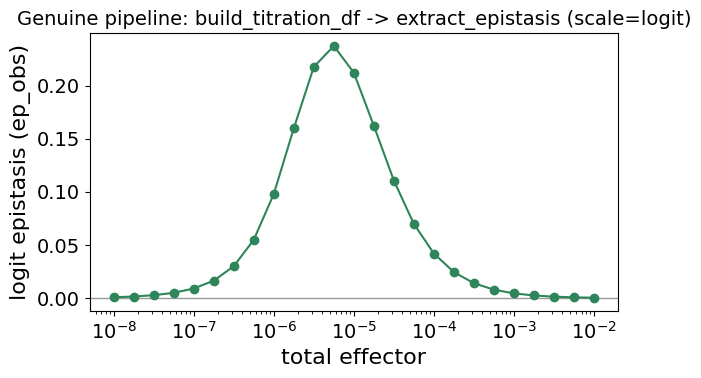

In [15]:
# The genuine pipeline for one channel: simulate a titration, extract logit
# epistasis, classify. This is what you'd run on real data.
from tfscreen.analysis.extract_epistasis import extract_epistasis

eff_cat = (MutationEffects()
           .add_mutation("A1V", H=2.0)      # contrasts H
           .add_mutation("A2V", LE=2.0))    # contrasts LE  -> cross H x LE, peak
titr = build_titration_df(mdl, effector, effects=eff_cat, observable_std=0.02)
ep = extract_epistasis(titr, y_obs="observable", y_std="observable_std",
                       group_by="titrant_conc", scale="logit")

fig, ax = plt.subplots(figsize=(6.5, 4))
sub = ep[ep["genotype"] == "A1V/A2V"]
ax.axhline(0, color="0.6", lw=1)
ax.semilogx(sub["titrant_conc"], sub["ep_obs"], "o-", color="#2f855a")
ax.set(xlabel="total effector", ylabel="logit epistasis (ep_obs)",
       title="Genuine pipeline: build_titration_df -> extract_epistasis (scale=logit)")
fig.tight_layout()

# Caveat: logit-propagated error near saturation is huge, so cat_response's
# magnitude gate ('fittable') will read False even though the SHAPE is a clean peak.
print("median ep_std (logit-propagated):", round(float(ep["ep_std"].median()), 2),
      "  <- why the screen above uses clean fixed-error curves for shape calls")

### Reading the screen

The two tables are the ground-truth **intrinsic** shape of each mechanism and the
shape `cat_response` **observes** at a realistic noise level. The mapping is clean:

- **Peaks/dips are a redistribution signature that touches $LE$.** Only `redist_*`
  channels that contrast an occupied apo state against $LE$ curve (`cross_H_LE`,
  `cross_L_LE` → *peak*; `same_LE` → *dip*). `cross_H_L` (no $LE$ contrast) is a
  monotone **step**.
- **Direct within-state interactions never peak.** `direct_e_LE`/`direct_e_H` are
  **steps**; `direct_e_HD` is a **flat** offset. A peak in real data therefore points
  to *redistribution across the ligand transition*, not a contact confined to one
  conformation.
- **The backdrop decides which peaks are alive — and this is a readout.** A
  $p_\cdot p_{LE}$ peak needs its partner apo state populated. In the observed table
  `cross_H_LE` is a clean peak in the H-dominant/mixed backdrops but washes to **flat**
  in L-dominant (H depopulated), while `cross_L_LE` does the mirror image — a peak
  where $L$ is populated, flat in H-dominant. **So which backdrops light a peak up
  tells you which conformation the pair redistributes between.**
- **Noise-free vs observed is a detectability lesson.** Where the intrinsic amplitude
  is small (a peak in a backdrop that depopulates the relevant state), `cat_response`
  correctly reads **flat** — the mechanism is there but undetectable at this noise.
- **The peak sits at the binding transition.** Its location is the wt ligand-transition
  midpoint to leading order; mutations that perturb $g_{LE}$ drag it toward their own
  shifted transition (a quartet blend, not strictly mutation-independent) — matching
  "right around the effector concentration over which binding occurs."

**Caveats for real data.** (1) Extract epistasis on **logit θ**, but read shape and
magnitude separately — logit error propagation explodes near saturation (previous
cell), so a clean peak can be flagged non-`fittable` by the magnitude gate even when
the shape is obvious. (2) Selector matters: `select_by='aicc'` (used here) is
conservative and reports only shapes you can trust, while `select_by='shape'` is the
liberal, exploratory classifier and will over-call structure on low-amplitude curves
— on perfectly noise-free curves it even chases solver-level micro-structure.

**Practical loop:** `basis_curves` + `plot_epistasis_decomposition` to reason about a
candidate mechanism, `epistasis_coeffs` to read which basis curve it activates, and
the backdrop screen to map mechanism → observed `cat_response` shape. You never
enumerate the doubles — you enumerate backdrops and channels.

---

## 10. Measurement range: when is a peak actually observable?

A peak that exists in `logit θ` is not the same as a peak you can *measure*.
Experimentally θ is only resolvable to some floor `eps` (say `0.01`): you cannot
tell `0.99` from `0.999`, or `0.01` from `0.0001`. That caps the usable logit scale
at `±L* = ±ln((1−eps)/eps) ≈ ±4.6`, and — importantly — the failure is
**one-sided**: `logit(0.99 ± 0.01)` runs over `[3.89, +∞)`. The symmetric
delta-method scale `σ/(θ(1−θ))` that the epistasis tools use blows up there but
cannot represent that infinite tail.

Two consequences drive everything below:

1. **Epistasis is a second difference**, so it is measurable only where **all four**
   genotypes (wt, A, B, AB) are simultaneously resolvable — the *intersection* of
   their windows.
2. **The peak location and the resolvable window are set by different constants.**
   The peak sits at the ligand transition (`K_eff`), but θ leaves saturation where
   `logit θ = ln_K_conf + ln_K_dna + ln[L]` passes through `±L*` — which moves with
   `ln_K_dna`. Tight DNA binding pins θ at 1 through the transition and **buries the
   peak in the saturated zone.**

In [16]:
from tfscreen.simulate.toy_thermo import (
    logit_ci, resolvable_logit, measurement_window, plot_measurement_window,
)

# (a) The asymmetric, one-sided logit CI from a theta measurement of +/- 0.01.
print(f"usable logit band: +/- {resolvable_logit(0.01):.3f}\n")
print(f"{'theta':>7} {'logit':>7} {'CI(z=1)':>18} {'delta-sd':>9}")
for th in (0.5, 0.9, 0.99, 0.999):
    c, lo, hi = logit_ci(np.array([th]), 0.01, z=1.0)
    hi_s = "+inf" if not np.isfinite(hi[0]) else f"{hi[0]:+.2f}"
    print(f"{th:>7} {c[0]:>+7.2f}  [{lo[0]:+6.2f}, {hi_s:>6}]  {0.01/(th*(1-th)):>8.2f}")

usable logit band: +/- 4.595

  theta   logit            CI(z=1)  delta-sd
    0.5   +0.00  [ -0.04,  +0.04]      0.04
    0.9   +2.20  [ +2.09,  +2.31]      0.11
   0.99   +4.60  [ +3.89,   +inf]      1.01
  0.999   +6.91  [ +4.50,   +inf]     10.01


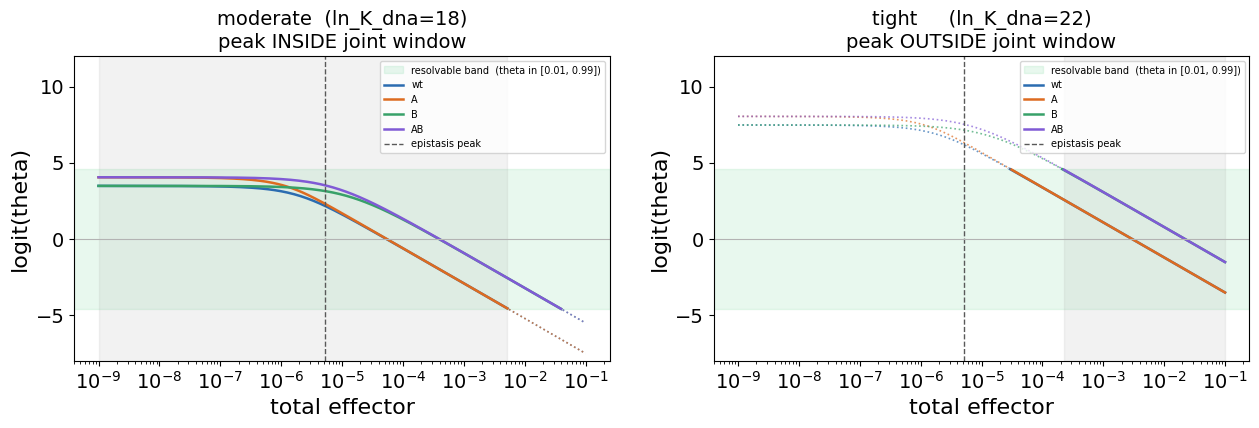

In [17]:
# (b) The same cross_H_LE peak in two constructs: a moderate repressor (peak
# resolvable) vs a tight one (peak buried in saturation). Shaded green = usable
# band; solid = resolvable, dotted = censored; grey span = joint window.
fine = np.logspace(-9, -1, 300)
constructs = {
    "moderate  (ln_K_dna=18)": ThermoModel(0.0, 18.0, 14.0, 1e-6, 1e-9),
    "tight     (ln_K_dna=22)": ThermoModel(0.0, 22.0, 14.0, 1e-6, 1e-9),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (label, mdl_c) in zip(axes, constructs.items()):
    plot_measurement_window(mdl_c, fine, {"H": 2.0}, {"LE": 2.0}, eps=0.01, ax=ax)
    ax.set_title(f"{label}\n{ax.get_title()}")
    ax.set_ylim(-8, 12)
fig.tight_layout()

In [18]:
# (c) Scan DNA affinity: how much of the true peak survives inside the joint
# measurement window. The peak location is fixed by K_eff; tightening ln_K_dna
# slides the resolvable window off it.
from tfscreen.simulate.toy_thermo import free_ensemble

a, b = {"H": 2.0}, {"LE": 2.0}
quartet = {"wt": {}, "A": a, "B": b, "AB": {"H": 2.0, "LE": 2.0}}
rows = []
for lnKd in (14, 18, 22, 26, 30):
    mdl_s = ThermoModel(0.0, lnKd, 14.0, 1e-6, 1e-9)
    ep = exact_epistasis(mdl_s, fine, a, b)
    i_pk = int(np.argmax(np.abs(ep)))
    win = measurement_window(mdl_s, fine, quartet, eps=0.01)["joint"]
    if win is None:
        captured, amp_in = False, 0.0
    else:
        inside = (fine >= win[0]) & (fine <= win[1])
        captured = win[0] <= fine[i_pk] <= win[1]
        amp_in = np.max(np.abs(ep[inside])) if inside.any() else 0.0
    rows.append({
        "ln_K_dna": lnKd,
        "theta@peak": round(float(mdl_s.observable(fine)[i_pk]), 4),
        "joint_window": None if win is None else f"{win[0]:.1e}..{win[1]:.1e}",
        "captured": captured,
        "true_peak": round(float(np.abs(ep[i_pk])), 3),
        "measurable": round(float(amp_in), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

 ln_K_dna  theta@peak     joint_window  captured  true_peak  measurable
       14      0.1395 1.0e-09..9.5e-05      True      0.237       0.237
       18      0.8984 1.0e-09..5.2e-03      True      0.238       0.238
       22      0.9979 2.2e-04..1.0e-01     False      0.238       0.020
       26      1.0000 1.2e-02..1.0e-01     False      0.238       0.000
       30      1.0000             None     False      0.238       0.000


### Reading Section 10

- **The edge failure is one-sided (panel a).** `θ = 0.99 ± 0.01` gives a logit CI
  `[3.89, +∞)` — the delta-method σ (`≈1.0`) is finite and symmetric and so
  understates it. Treat points with θ outside `[eps, 1−eps]` as *bounds*, not
  measurements.
- **Same peak, different construct (panel b).** At `ln_K_dna=18` the quartet's
  `logit θ` sweeps through the green band right where the peak sits → *captured*. At
  `ln_K_dna=22` the curves are pinned near the top rail (dotted = censored) across
  the transition, and the peak sits to the **left** of the joint window → *lost*,
  even though the underlying thermodynamics are unchanged.
- **The scan quantifies it (panel c).** As `ln_K_dna` rises, `θ@peak → 1` and the
  measurable amplitude collapses (`0.24 → 0.02 → 0`) while the *true* peak is
  constant. **A peak is observable only when repression is intermediate at the
  peak's effector concentration.**

**Operational recipe.** Your model-free measurement window is
`measurement_window(model, fine_grid, {"wt":{}, "A":…, "B":…, "AB":…})["joint"]` —
the effector range where all four are resolvable. A peak is trustworthy only if its
location falls inside it. To *recover* a peak that lies outside, you must assert the
thermodynamic model and extrapolate; quantify how much you're leaning on that by
refitting with vs without the censored points and watching the peak estimate and its
CI move. Design knob: pick a construct/`protein_total`/operator strength so θ is
mid-range (not saturated) across the effector concentrations where the peak lives —
otherwise a tight repressor hides its own allosteric epistasis.